# Model Building

### Import the required libraries

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import warnings
import os
import xgboost as xgb
import lightgbm as lgb
import optuna
import shap
import matplotlib.gridspec as gridspec

warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.dummy import DummyRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import KFold

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

os.makedirs("figures", exist_ok=True)

### Load the data

In [26]:
df = pd.read_csv('../data/OnlineNewsPopularityEngineered.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (38463, 59)


,n_tokens_title,n_unique_tokens,average_token_length,num_keywords,data_channel_is_lifestyle,data_channel_is_entertainment,data_channel_is_bus,data_channel_is_socmed,data_channel_is_tech,data_channel_is_world,kw_min_min,kw_max_max,kw_min_avg,weekday_is_monday,weekday_is_tuesday,weekday_is_wednesday,weekday_is_thursday,weekday_is_friday,weekday_is_saturday,weekday_is_sunday,is_weekend,LDA_00,LDA_01,LDA_02,LDA_03,LDA_04,global_subjectivity,global_sentiment_polarity,global_rate_positive_words,global_rate_negative_words,rate_positive_words,avg_positive_polarity,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,n_tokens_content_log,num_hrefs_log,num_self_hrefs_log,num_imgs_log,num_videos_log,kw_avg_min_log,kw_min_max_log,self_reference_avg_shares_log,kw_avg_avg_log,kw_avg_max_log,shares_log,is_short_article,is_long_article,has_image,has_video,content_to_links_ratio,keyword_quality_score,sentiment_gap
0,12.0,0.663594,4.680365,5.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.500331,0.378279,0.040005,0.041263,0.040123,0.521617,0.092562,0.045662,0.013699,0.769231,0.378636,0.100000,0.7,-0.350000,-0.600,-0.200000,0.500000,-0.187500,0.000000,0.187500,5.393628,1.609438,1.098612,0.693147,0.0,0.0,0.0,6.208590,0.0,0.0,6.386879,1,0,1,0,2.066969,0.0,0.280062
1,9.0,0.604743,4.913725,4.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.799756,0.050047,0.050096,0.050101,0.050001,0.341246,0.148948,0.043137,0.015686,0.733333,0.286915,0.033333,0.7,-0.118750,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000,5.545177,1.386294,0.693147,0.693147,0.0,0.0,0.0,0.000000,0.0,0.0,6.568078,0,0,1,0,2.323761,0.0,0.148948
2,9.0,0.575130,4.393365,6.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.217792,0.033334,0.033351,0.033334,0.682188,0.702222,0.323333,0.056872,0.009479,0.857143,0.495833,0.100000,1.0,-0.466667,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000,5.356586,1.386294,0.693147,0.693147,0.0,0.0,0.0,6.823286,0.0,0.0,7.313887,1,0,1,0,2.244730,0.0,0.323333
3,9.0,0.503788,4.404896,7.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.028573,0.419300,0.494651,0.028905,0.028572,0.429850,0.100705,0.041431,0.020716,0.666667,0.385965,0.136364,0.8,-0.369697,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000,6.276643,2.302585,0.000000,0.693147,0.0,0.0,0.0,0.000000,0.0,0.0,7.090910,0,0,1,0,1.900524,0.0,0.100705
4,13.0,0.415646,4.682836,7.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.028633,0.028794,0.028575,0.028572,0.885427,0.513502,0.281003,0.074627,0.012127,0.860215,0.411127,0.033333,1.0,-0.220192,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364,6.978214,2.995732,2.995732,3.044522,0.0,0.0,0.0,8.055843,0.0,0.0,6.226537,0,1,1,0,1.746417,0.0,0.144640


### 3. Train / Test Split

In [27]:
X = df.drop(columns=['shares_log'])
y = df['shares_log']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Target mean (train): {y_train.mean():.4f}")
print(f"Target mean (test):  {y_test.mean():.4f}")

Train: (30770, 58) | Test: (7693, 58)
Target mean (train): 7.4703
Target mean (test):  7.4694


### 4. Preprocessing Pipeline
Continuous features are standardised; binary (0/1) features are passed through unchanged.

In [28]:
numeric_cols   = X_train.select_dtypes(include=np.number).columns.tolist()
binary_cols    = [col for col in numeric_cols if X_train[col].nunique() == 2]
continuous_cols = [col for col in numeric_cols if col not in binary_cols]

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), continuous_cols),
    ('bin', 'passthrough',    binary_cols)
])

print(f"Continuous features : {len(continuous_cols)}")
print(f"Binary features     : {len(binary_cols)}")

Continuous features : 40
Binary features     : 18


### 5. Evaluation Helper

In [29]:
def evaluate_model(name, model):
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    # 5-fold CV RMSE on log-scale (train only — no test leakage)
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(
        pipeline, X_train, y_train,
        scoring='neg_root_mean_squared_error', cv=kf
    )

    # Fit and predict
    pipeline.fit(X_train, y_train)
    y_pred_log = pipeline.predict(X_test)

    # R² on log scale — meaningful because model optimised in this space
    r2 = r2_score(y_test, y_pred_log)

    # RMSE / MAE on original share counts — interpretable magnitude
    y_pred_orig = np.expm1(y_pred_log)
    y_test_orig = np.expm1(y_test)
    rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred_orig))
    mae  = mean_absolute_error(y_test_orig, y_pred_orig)

    return {
        'model'   : name,
        'pipeline': pipeline,
        'r2'      : r2,       # log-scale
        'rmse'    : rmse,     # original-scale shares
        'mae'     : mae,      # original-scale shares
        'cv_rmse' : -cv_scores.mean()  # log-scale
    }

### 6. Baseline & Model Benchmarking

In [30]:
results = []

# Baseline
results.append(evaluate_model(
    'Dummy (mean)', 
    DummyRegressor(strategy='mean')
    )
)

# Linear models
results.append(evaluate_model(
    'Linear Regression', 
    LinearRegression()
    )
)

results.append(evaluate_model(
    'Ridge (alpha=1.0)', 
    Ridge(alpha=1.0)
    )
)

results.append(evaluate_model(
    'Lasso (alpha=0.01)', 
    Lasso(alpha=0.01, max_iter=5000)
    )
)

# Tree models
results.append(evaluate_model(
    'Random Forest',
    RandomForestRegressor(
        n_estimators=200, 
        random_state=42, 
        n_jobs=-1)
    )
)

results.append(evaluate_model(
    'Gradient Boosting',
    GradientBoostingRegressor(
        n_estimators=200, 
        learning_rate=0.05,
        max_depth=4, 
        random_state=42))
)

results.append(evaluate_model('XGBoost',
    xgb.XGBRegressor(
        n_estimators=200, 
        learning_rate=0.05, 
        max_depth=4,
        random_state=42, 
        verbosity=0, 
        n_jobs=-1)
    )
)

results.append(evaluate_model('LightGBM',
    lgb.LGBMRegressor(
        n_estimators=200, 
        learning_rate=0.05, 
        max_depth=4,
        random_state=42, 
        verbosity=-1, 
        n_jobs=-1)
    )
)

### 7. Results Comparison


Base Model Comparison (rmse & mae original-scale | r2 and cv_rmse log-scale)

             model         rmse         mae        r2  cv_rmse
          LightGBM 12006.474072 2289.957477  0.161279 0.842932
           XGBoost 12007.136677 2288.633242  0.160710 0.842846
 Gradient Boosting 12009.021716 2292.638083  0.157689 0.844412
     Random Forest 11996.635648 2311.190205  0.151463 0.851186
 Linear Regression 12026.305495 2318.633967  0.124791 0.858349
 Ridge (alpha=1.0) 12026.302455 2318.627858  0.124788 0.858347
Lasso (alpha=0.01) 12038.759965 2325.735107  0.112132 0.867510
      Dummy (mean) 12093.247886 2407.813597 -0.000001 0.924683


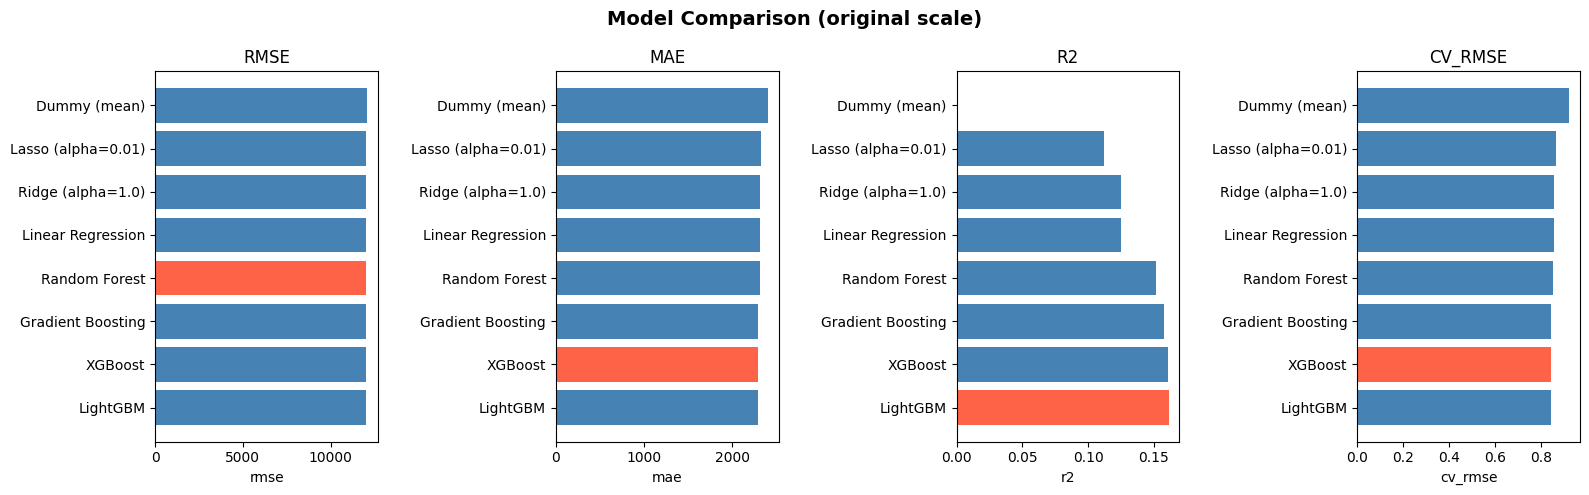

Best base model: LightGBM


In [31]:
base_df = pd.DataFrame(
    [{k: v for k, v in r.items() if k not in ('pipeline',)} for r in results]
).sort_values('r2', ascending=False)

print("\nBase Model Comparison (rmse & mae original-scale | r2 and cv_rmse log-scale)\n")
print(base_df[['model', 'rmse', 'mae', 'r2', 'cv_rmse']].to_string(index=False))

# Comparison chart
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle('Model Comparison (original scale)', fontsize=14, fontweight='bold')

for i, (metric, best_fn) in enumerate([('rmse', 'idxmin'), ('mae', 'idxmin'), ('r2', 'idxmax'), ('cv_rmse', 'idxmin')]):
    best_idx = getattr(base_df[metric], best_fn)()
    colors = ['tomato' if idx == best_idx else 'steelblue' for idx in base_df.index]
    axes[i].barh(base_df['model'], base_df[metric], color=colors)
    axes[i].set_title(metric.upper())
    axes[i].set_xlabel(metric)

plt.tight_layout()
plt.savefig('../figures/model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

best_base_name = base_df.iloc[0]['model']
print(f"Best base model: {best_base_name}")

### 8. Manual Hyperparameter Tuning (LightGBM)
Three hand-crafted configs to explore the speed/depth/learning-rate trade-off before letting Optuna search more broadly.

In [32]:
manual_configs = [
    {'label': 'Manual 1 — shallow/fast',  'n_estimators': 100, 'learning_rate': 0.1,  'max_depth': 3},
    {'label': 'Manual 2 — balanced',      'n_estimators': 300, 'learning_rate': 0.05, 'max_depth': 5},
    {'label': 'Manual 3 — deep/slow',     'n_estimators': 500, 'learning_rate': 0.03, 'max_depth': -1},
]

manual_results = []
for cfg in manual_configs:
    label  = cfg.pop('label')
    result = evaluate_model(label, lgb.LGBMRegressor(**cfg, random_state=42, verbosity=-1))
    result.update(cfg)          # store the params alongside the metrics
    manual_results.append(result)
    cfg['label'] = label        # restore for clarity

manual_df = pd.DataFrame(
    [{k: v for k, v in r.items() if k != 'pipeline'} for r in manual_results]
).sort_values('rmse')

print("\nManual Tuning Results\n")
print(manual_df[['model', 'n_estimators', 'learning_rate', 'max_depth', 'rmse', 'mae', 'r2']].to_string(index=False))


Manual Tuning Results

                  model  n_estimators  learning_rate  max_depth         rmse         mae       r2
    Manual 2 — balanced           300           0.05          5 11999.039926 2287.135788 0.167064
   Manual 3 — deep/slow           500           0.03         -1 12002.276101 2289.243300 0.165412
Manual 1 — shallow/fast           100           0.10          3 12011.884610 2294.563360 0.154004


### 9. Hyperparameter Tuning with Optuna (LightGBM)
Richer search space: 9 parameters, 50 trials, log-scale learning rate, subsampling, regularisation.

In [33]:
def objective(trial):
    params = {
        'n_estimators'     : trial.suggest_int  ('n_estimators',     200,  1000),
        'learning_rate'    : trial.suggest_float('learning_rate',    0.01, 0.3,  log=True),
        'max_depth'        : trial.suggest_int  ('max_depth',        3,    12),
        'num_leaves'       : trial.suggest_int  ('num_leaves',       20,   150),
        'min_child_samples': trial.suggest_int  ('min_child_samples',10,   100),
        'subsample'        : trial.suggest_float('subsample',        0.5,  1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5,  1.0),
        'reg_alpha'        : trial.suggest_float('reg_alpha',        1e-8, 10.0, log=True),
        'reg_lambda'       : trial.suggest_float('reg_lambda',       1e-8, 10.0, log=True),
        'random_state'     : 42,
        'verbose'          : -1,
    }

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', lgb.LGBMRegressor(**params))
    ])

    scores = cross_val_score(
        pipeline, X_train, y_train,
        scoring='neg_root_mean_squared_error', cv=5  # changed to 5 folds
    )
    return -scores.mean()


def print_callback(study, trial):
    print(f"Trial {trial.number:>3} | CV RMSE: {trial.value:.4f} | Best so far: {study.best_value:.4f}")


optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50, callbacks=[print_callback])

best_params = study.best_params
best_params = {**best_params, 'random_state': 42}
print(f"\nBest CV RMSE (log scale): {study.best_value:.4f}")
print("Best params:", best_params)

Trial   0 | CV RMSE: 0.8416 | Best so far: 0.8416
Trial   1 | CV RMSE: 0.8483 | Best so far: 0.8416
Trial   2 | CV RMSE: 0.8427 | Best so far: 0.8416
Trial   3 | CV RMSE: 0.8416 | Best so far: 0.8416
Trial   4 | CV RMSE: 0.8422 | Best so far: 0.8416
Trial   5 | CV RMSE: 0.8709 | Best so far: 0.8416
Trial   6 | CV RMSE: 0.8429 | Best so far: 0.8416
Trial   7 | CV RMSE: 0.8635 | Best so far: 0.8416
Trial   8 | CV RMSE: 0.8774 | Best so far: 0.8416
Trial   9 | CV RMSE: 0.8963 | Best so far: 0.8416
Trial  10 | CV RMSE: 0.8385 | Best so far: 0.8385
Trial  11 | CV RMSE: 0.8390 | Best so far: 0.8385
Trial  12 | CV RMSE: 0.8376 | Best so far: 0.8376
Trial  13 | CV RMSE: 0.8382 | Best so far: 0.8376
Trial  14 | CV RMSE: 0.8390 | Best so far: 0.8376
Trial  15 | CV RMSE: 0.8401 | Best so far: 0.8376
Trial  16 | CV RMSE: 0.8394 | Best so far: 0.8376
Trial  17 | CV RMSE: 0.8396 | Best so far: 0.8376
Trial  18 | CV RMSE: 0.8398 | Best so far: 0.8376
Trial  19 | CV RMSE: 0.8393 | Best so far: 0.8376


### Optuna Optimisation History

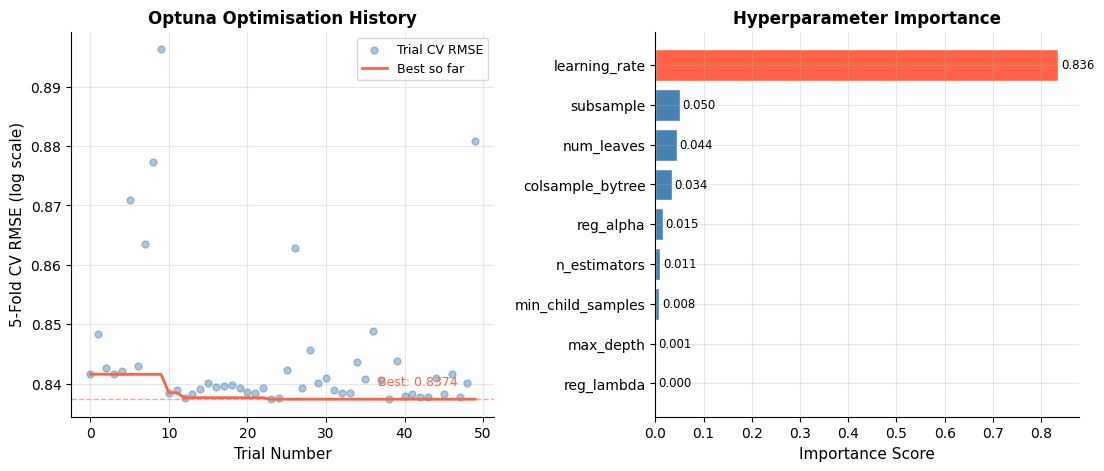

In [34]:
trials   = [t for t in study.trials if t.value is not None]
t_nums   = [t.number for t in trials]
t_vals   = [t.value  for t in trials]
t_best   = np.minimum.accumulate(t_vals)
 
fig = plt.figure(figsize=(13, 5))
gs  = gridspec.GridSpec(1, 2, wspace=0.38)
 
# Left — trial history + running best
ax1 = fig.add_subplot(gs[0])
ax1.scatter(t_nums, t_vals,
            color='steelblue', alpha=0.45, s=25,
            label='Trial CV RMSE', zorder=2)
ax1.plot(t_nums, t_best,
         color='tomato', linewidth=2,
         label='Best so far', zorder=3)
ax1.axhline(t_best[-1], color='tomato',
            linestyle='--', linewidth=1, alpha=0.6)
ax1.annotate(f"Best: {t_best[-1]:.4f}",
             xy=(t_nums[-1], t_best[-1]),
             xytext=(-70, 10), textcoords='offset points',
             fontsize=9, color='tomato')
ax1.set_xlabel('Trial Number', fontsize=11)
ax1.set_ylabel('5-Fold CV RMSE (log scale)', fontsize=11)
ax1.set_title('Optuna Optimisation History',
              fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(alpha=0.3)
 
# Right — hyperparameter importance
ax2 = fig.add_subplot(gs[1])
try:
    from optuna.importance import get_param_importances
    imp    = get_param_importances(study)
    params = list(imp.keys())
    scores = list(imp.values())
    colors = ['tomato' if s == max(scores) else 'steelblue' for s in scores]
    bars   = ax2.barh(params[::-1], scores[::-1],
                      color=colors[::-1], edgecolor='white')
    for bar, s in zip(bars, scores[::-1]):
        ax2.text(bar.get_width() + 0.005,
                 bar.get_y() + bar.get_height() / 2,
                 f'{s:.3f}', va='center', fontsize=8.5)
    ax2.set_xlabel('Importance Score', fontsize=11)
    ax2.set_title('Hyperparameter Importance',
                  fontsize=12, fontweight='bold')
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.grid(alpha=0.3)
except Exception:
    ax2.text(0.5, 0.5,
             'Install scikit-learn to\nenable importance scores',
             ha='center', va='center',
             transform=ax2.transAxes, fontsize=10)
    ax2.set_title('Hyperparameter Importance',
                  fontsize=12, fontweight='bold')
 
plt.savefig('../figures/optuna_history.png', dpi=300, bbox_inches='tight')
plt.show()

### LightGBM Learning Curve (Train vs Validation)

  Fold 1/5 complete
  Fold 2/5 complete
  Fold 3/5 complete
  Fold 4/5 complete
  Fold 5/5 complete


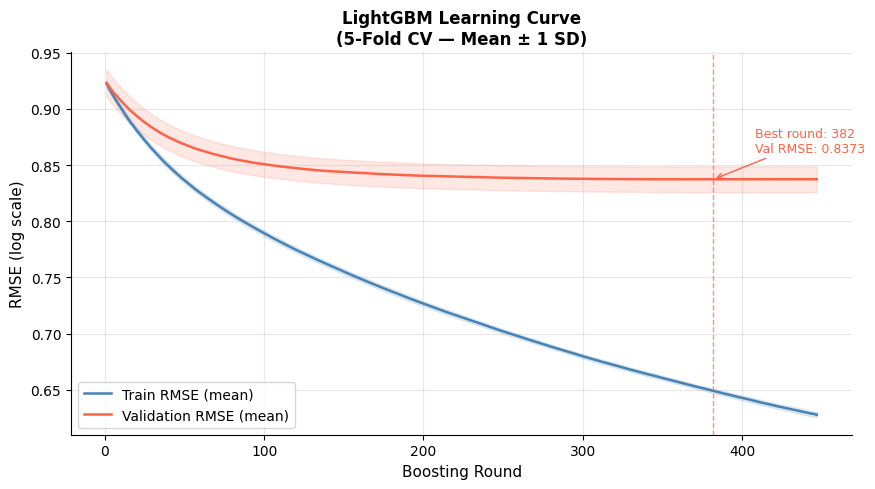

In [38]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
 
train_curves = []
val_curves   = []
 
# Use best_params from Optuna; strip keys not accepted by lgb.train
lgb_params = {
    **best_params,
    'objective' : 'regression',
    'metric'    : 'rmse',
    'verbosity' : -1,
    'n_jobs'    : -1,
    'seed'      : 42,
}
n_rounds = best_params.get('n_estimators', 447)
 
# Preprocess X_train once (fit on full train, transform per fold inside loop)
X_train_proc = preprocessor.fit_transform(X_train)
 
for fold, (tr_idx, val_idx) in enumerate(kf.split(X_train_proc)):
    X_tr,  X_val  = X_train_proc[tr_idx], X_train_proc[val_idx]
    y_tr,  y_val  = y_train.iloc[tr_idx],  y_train.iloc[val_idx]
 
    dtrain = lgb.Dataset(X_tr,  label=y_tr)
    dval   = lgb.Dataset(X_val, label=y_val, reference=dtrain)
 
    evals  = {}
    lgb.train(
        lgb_params,
        dtrain,
        num_boost_round=n_rounds,
        valid_sets=[dtrain, dval],
        valid_names=['train', 'valid'],
        callbacks=[lgb.record_evaluation(evals),
                   lgb.log_evaluation(period=-1)]
    )
 
    train_curves.append(evals['train']['rmse'])
    val_curves.append(evals['valid']['rmse'])
    print(f"  Fold {fold + 1}/5 complete")
 
# Align lengths across folds
min_len     = min(len(c) for c in train_curves)
train_arr   = np.array([c[:min_len] for c in train_curves])
val_arr     = np.array([c[:min_len] for c in val_curves])
 
rounds      = np.arange(1, min_len + 1)
train_mean  = train_arr.mean(axis=0)
train_std   = train_arr.std(axis=0)
val_mean    = val_arr.mean(axis=0)
val_std     = val_arr.std(axis=0)
 
best_round  = int(np.argmin(val_mean)) + 1
 
fig, ax = plt.subplots(figsize=(9, 5))
 
ax.plot(rounds, train_mean, color='steelblue',
        linewidth=1.8, label='Train RMSE (mean)')
ax.fill_between(rounds,
                train_mean - train_std,
                train_mean + train_std,
                alpha=0.15, color='steelblue')
 
ax.plot(rounds, val_mean, color='tomato',
        linewidth=1.8, label='Validation RMSE (mean)')
ax.fill_between(rounds,
                val_mean - val_std,
                val_mean + val_std,
                alpha=0.15, color='tomato')
 
ax.axvline(best_round, color='tomato',
           linestyle='--', linewidth=1, alpha=0.7)
ax.annotate(
    f'Best round: {best_round}\nVal RMSE: {val_mean[best_round - 1]:.4f}',
    xy=(best_round, val_mean[best_round - 1]),
    xytext=(30, 20), textcoords='offset points',
    fontsize=9, color='tomato',
    arrowprops=dict(arrowstyle='->', color='tomato', lw=1)
)
 
ax.set_xlabel('Boosting Round', fontsize=11)
ax.set_ylabel('RMSE (log scale)', fontsize=11)
ax.set_title('LightGBM Learning Curve\n(5-Fold CV — Mean ± 1 SD)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(alpha=0.3)
 
plt.tight_layout()
plt.savefig('../figures/learning_curve.png', dpi=300, bbox_inches='tight')
plt.show()

### 10. Final Model Evaluation

In [37]:
optuna_result = evaluate_model(
    'LightGBM (Optuna)',
    lgb.LGBMRegressor(**best_params)
)

final_df = pd.DataFrame(
    [{k: v for k, v in r.items() if k != 'pipeline'} for r in results] +
    [{k: v for k, v in r.items() if k != 'pipeline'} for r in manual_results] +
    [{k: v for k, v in optuna_result.items() if k != 'pipeline'}]
).sort_values('r2', ascending=False)

print("\nFINAL COMPARISON (original-scale metrics)\n")
final_df[['model', 'rmse', 'mae', 'r2', 'cv_rmse']].style\
    .format({
        'rmse'    : '{:,.2f}',
        'mae'     : '{:,.2f}',
        'r2'      : '{:.4f}',
        'cv_rmse' : '{:.4f}'
    })\
    .background_gradient(subset=['r2'],      cmap='RdYlGn')\
    .background_gradient(subset=['rmse'],    cmap='RdYlGn_r')\
    .background_gradient(subset=['mae'],     cmap='RdYlGn_r')\
    .background_gradient(subset=['cv_rmse'], cmap='RdYlGn_r')\
    .hide(axis='index')


FINAL COMPARISON (original-scale metrics)



model,rmse,mae,r2,cv_rmse
LightGBM (Optuna),"11,998.84","2,283.09",0.1739,0.8374
Manual 2 — balanced,"11,999.04","2,287.14",0.1671,0.8416
Manual 3 — deep/slow,"12,002.28","2,289.24",0.1654,0.8419
LightGBM,"12,006.47","2,289.96",0.1613,0.8429
XGBoost,"12,007.14","2,288.63",0.1607,0.8428
Gradient Boosting,"12,009.02","2,292.64",0.1577,0.8444
Manual 1 — shallow/fast,"12,011.88","2,294.56",0.1540,0.8458
Random Forest,"11,996.64","2,311.19",0.1515,0.8512
Linear Regression,"12,026.31","2,318.63",0.1248,0.8583
Ridge (alpha=1.0),"12,026.30","2,318.63",0.1248,0.8583


### 11. SHAP Explanations
Using `TreeExplainer` directly on `X_test` so feature names are preserved in plots.

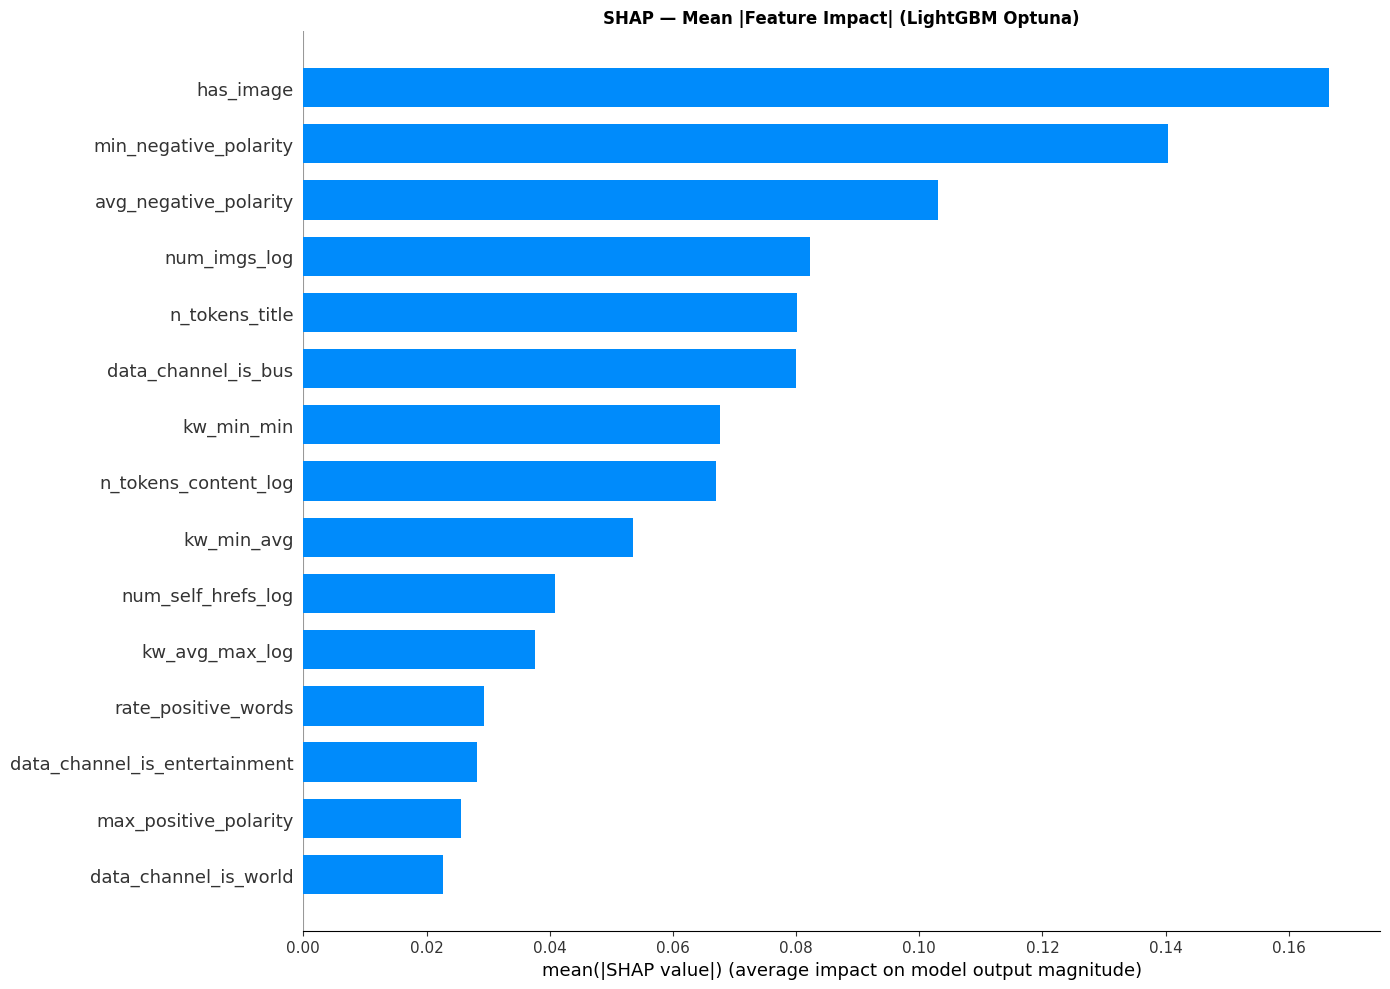

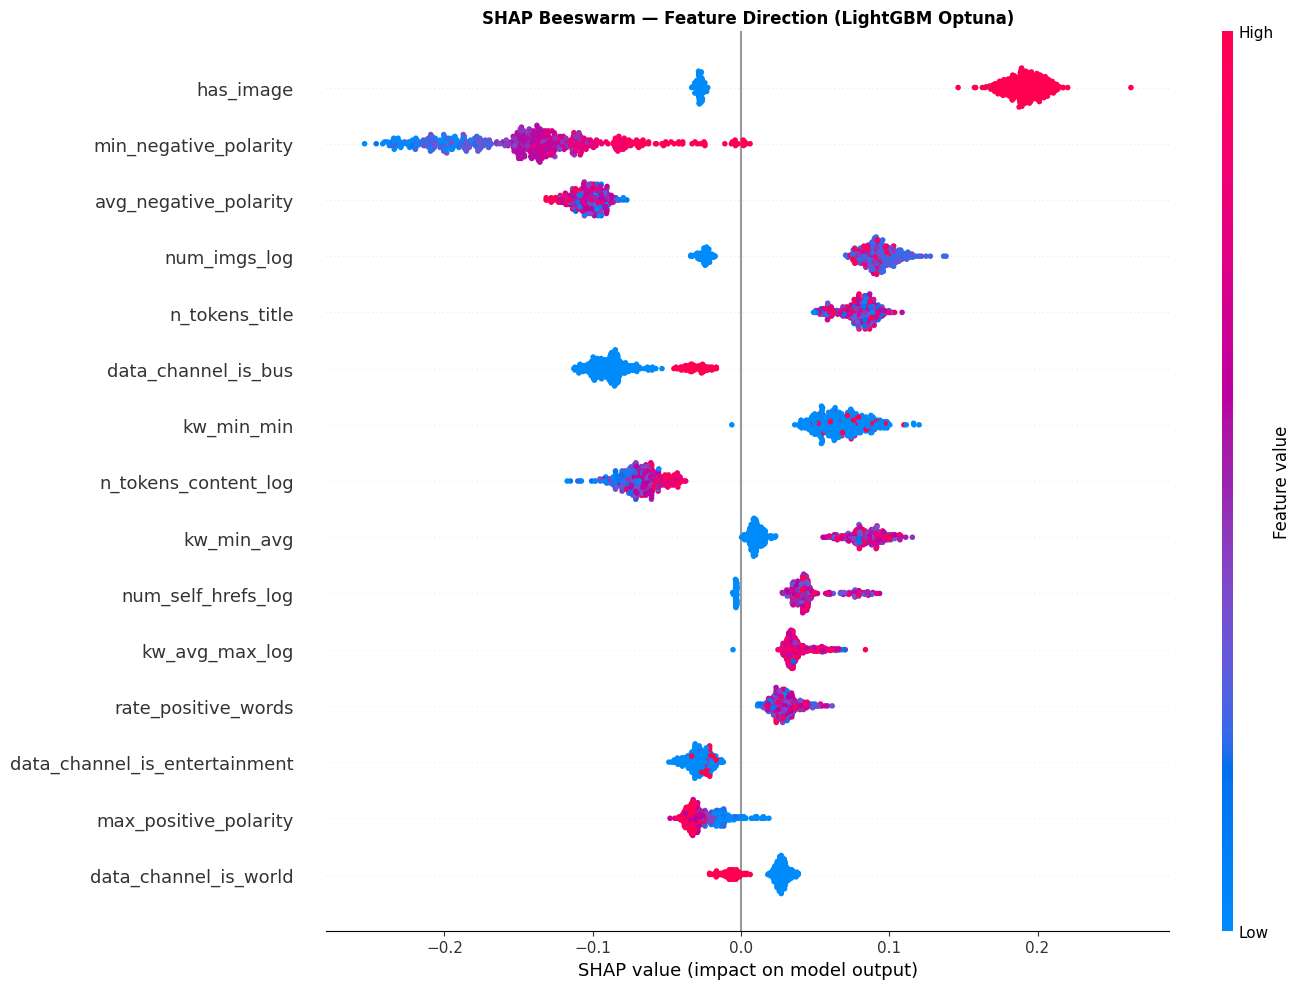

In [ ]:
best_pipeline = optuna_result['pipeline']
best_lgbm     = best_pipeline.named_steps['model']

sample_size = min(500, len(X_test))
X_shap = X_test.iloc[:sample_size]

explainer   = shap.TreeExplainer(best_lgbm)
shap_values = explainer.shap_values(X_shap)

# Bar summary — mean |SHAP|
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_shap, plot_type='bar', max_display=15, show=False)
plt.title('SHAP — Mean |Feature Impact| (LightGBM Optuna)', fontweight='bold')
plt.gcf().set_size_inches(14, 10)
plt.tight_layout()
plt.savefig('../figures/SHAP_bar_summary.png', dpi=300, bbox_inches='tight')
plt.show()

# Beeswarm — direction of impact
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_shap, max_display=15, show=False)
plt.title('SHAP Beeswarm — Feature Direction (LightGBM Optuna)', fontweight='bold')
plt.gcf().set_size_inches(14, 10)
plt.tight_layout()
plt.savefig('../figures/beeswarm.png', dpi=300, bbox_inches='tight')
plt.show()

### Predictions vs Actuals on Test Set

In [ ]:
# Predict on test set
y_pred_log  = best_pipeline.predict(X_test)

# Back-transform to original share counts
y_pred_orig = np.expm1(y_pred_log)
y_test_orig = np.expm1(y_test)

# Prediction vs Actual table
pred_df = pd.DataFrame({
    'Actual Shares'   : y_test_orig.values,
    'Predicted Shares': y_pred_orig,
    'Difference'      : y_test_orig.values - y_pred_orig
}).reset_index(drop=True)

print(f"\nPrediction vs Actual (5 sample articles)\n")
pred_df.sample(5).style\
    .format({
        'Actual Shares'   : '{:,.0f}',
        'Predicted Shares': '{:,.0f}',
        'Difference'      : '{:,.0f}'
    })\
    .background_gradient(subset=['Difference'], cmap='RdYlGn')


Prediction vs Actual (5 sample articles)



,Actual Shares,Predicted Shares,Difference
6629,"3,300","2,075","1,225"
5532,"1,700","1,504",196
2621,769,"1,686",-917
4651,"2,800","4,524","-1,724"
4615,648,"1,359",-711


### Actual vs. Predicted scatter plot

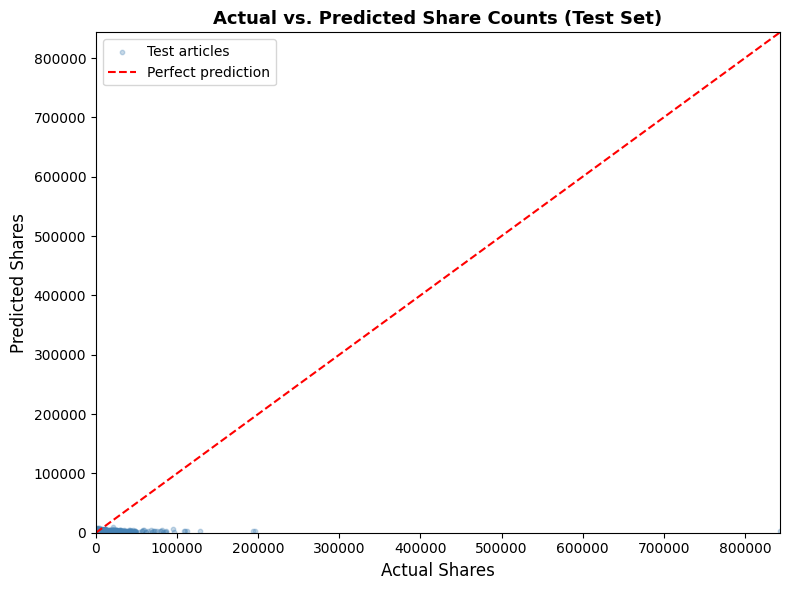

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(y_test_orig, y_pred_orig, alpha=0.3, s=10, color='steelblue', label='Test articles')

# Perfect prediction line
max_val = max(y_test_orig.max(), y_pred_orig.max())
ax.plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='Perfect prediction')

ax.set_xlabel('Actual Shares', fontsize=12)
ax.set_ylabel('Predicted Shares', fontsize=12)
ax.set_title('Actual vs. Predicted Share Counts (Test Set)', fontsize=13, fontweight='bold')
ax.legend()
ax.set_xlim(0, max_val)
ax.set_ylim(0, max_val)

plt.tight_layout()
plt.savefig('../figures/actual_vs_predicted.png', dpi=300, bbox_inches='tight')
plt.show()

### Residual distribution

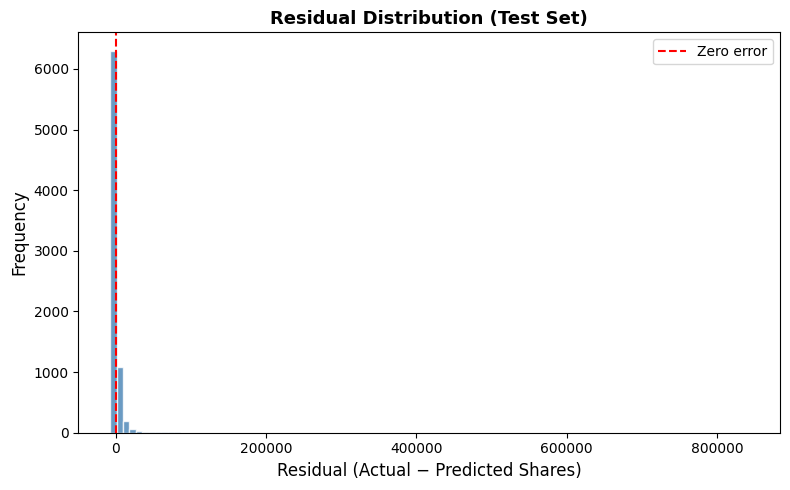

In [ ]:
residuals = y_test_orig.values - y_pred_orig

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(residuals, bins=100, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero error')
ax.set_xlabel('Residual (Actual − Predicted Shares)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Residual Distribution (Test Set)', fontsize=13, fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig('../figures/residual_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

### 12. Save Best Model & Results

In [ ]:
model_filename = '../models/best_model_lightgbm_optuna.pkl'
with open(model_filename, 'wb') as f:
    pickle.dump(best_pipeline, f)
print(f"Saved pipeline: {model_filename}")

final_df.to_csv('../models/model_results.csv', index=False)
print("Saved results: ../models/model_results.csv")

Saved pipeline: ../models/best_model_lightgbm_optuna.pkl
Saved results: ../models/model_results.csv
